<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Linear_%26_Logistic_Regression_HandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/new_insurance_data (1) (1).csv')

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [ ]:
df.dtypes

,0
age,float64
sex,object
bmi,float64
children,float64
smoker,object
Claim_Amount,float64
past_consultations,float64
num_of_steps,float64
Hospital_expenditure,float64
NUmber_of_past_hospitalizations,float64


In [ ]:
df.shape

(1338, 13)

In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum(axis = 0)

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df["age"] = df["age"].fillna(df["age"].mean())

In [ ]:
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

In [ ]:
df["children"] = df["children"].fillna(df["children"].mean())

In [ ]:
df["Claim_Amount"] = df["Claim_Amount"].fillna(df["Claim_Amount"].mean())

In [ ]:
df["past_consultations"] = df["past_consultations"].fillna(df["past_consultations"].mean())

In [ ]:
df["num_of_steps"] = df["num_of_steps"].fillna(df["num_of_steps"].mean())

In [ ]:
df["Hospital_expenditure"] = df["Hospital_expenditure"].fillna(df["Hospital_expenditure"].mean())

In [ ]:
df["NUmber_of_past_hospitalizations"] = df["NUmber_of_past_hospitalizations"].fillna(df["NUmber_of_past_hospitalizations"].mean())

In [ ]:
df["Anual_Salary"] = df["Anual_Salary"].fillna(df["Anual_Salary"].mean())

In [ ]:
df.isnull().sum(axis = 0)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [ ]:
for i in df.columns:
  if df[i].dtype !="object":
    df[i]=df[i].fillna(df[i].mean())

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [ ]:
# Duplicate--->
df.duplicated().sum()

np.int64(0)

In [ ]:
#but if the duplicate  value are there then->

# df.duplicates(inplace=True)

In [ ]:
#Outliers

In [ ]:
# for column in df.select_dtypes(include="number").columns:
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     print(f"\nOutliers in {column}:")
#     for value in df[column]:
#         if value < lower or value > upper:
#             print(value)

In [ ]:
for column in df.select_dtypes(include='number').columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    if len(outliers) > 0:
        print(f"{column} has {len(outliers)} outlier(s)")
    else:
        print(f"{column} has no outliers")

age has no outliers
bmi has 9 outlier(s)
children has no outliers
Claim_Amount has no outliers
past_consultations has 5 outlier(s)
num_of_steps has no outliers
Hospital_expenditure has 201 outlier(s)
NUmber_of_past_hospitalizations has 381 outlier(s)
Anual_Salary has 192 outlier(s)
charges has 139 outlier(s)


In [ ]:
import matplotlib.pyplot as plt


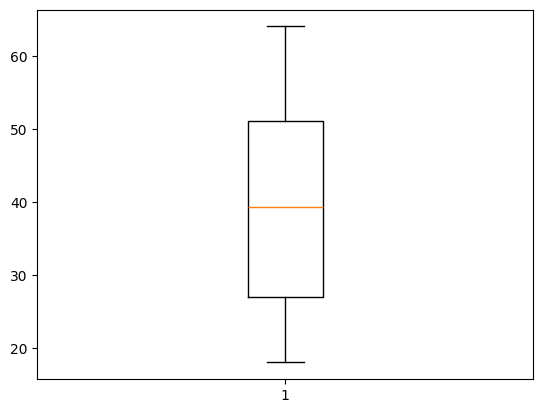

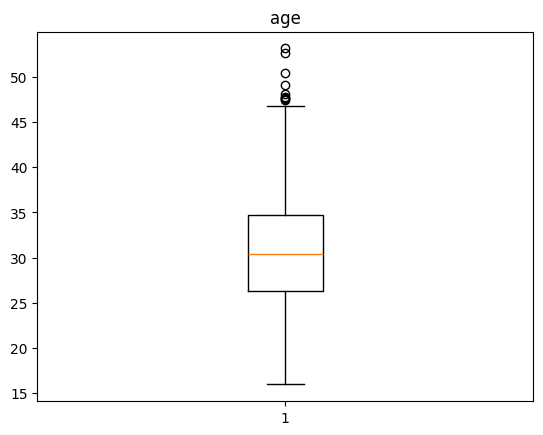

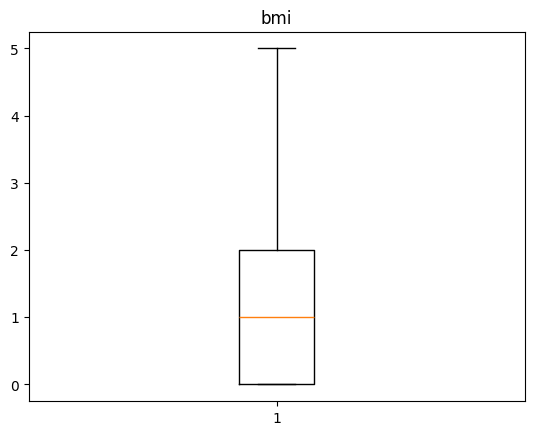

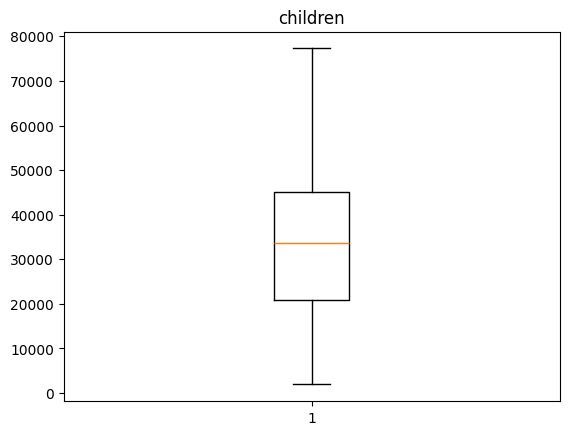

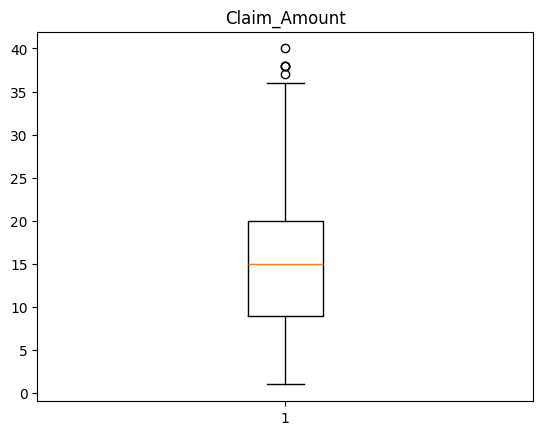

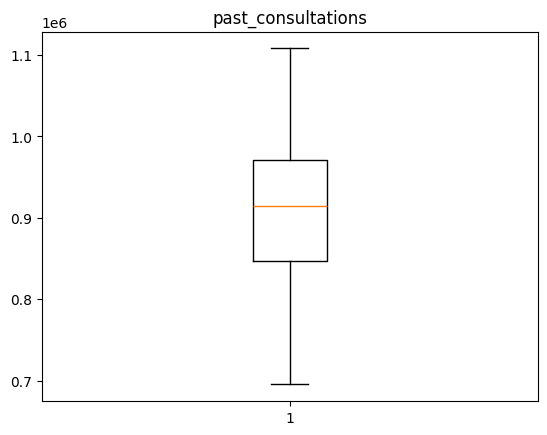

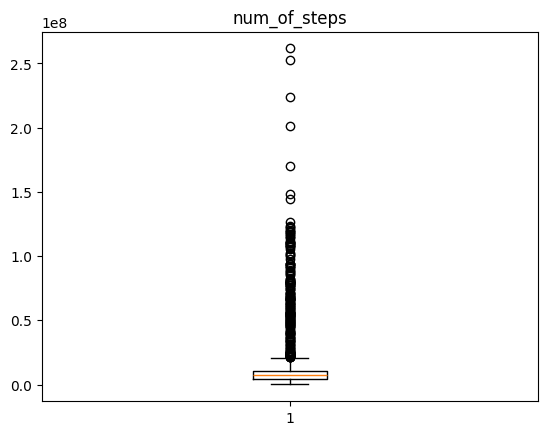

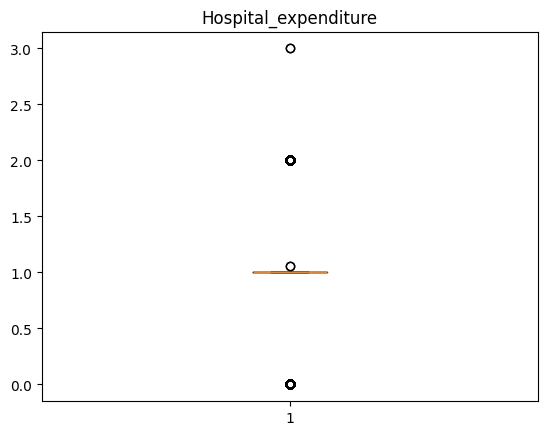

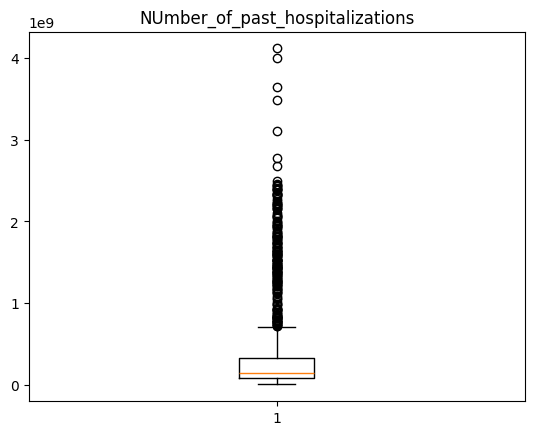

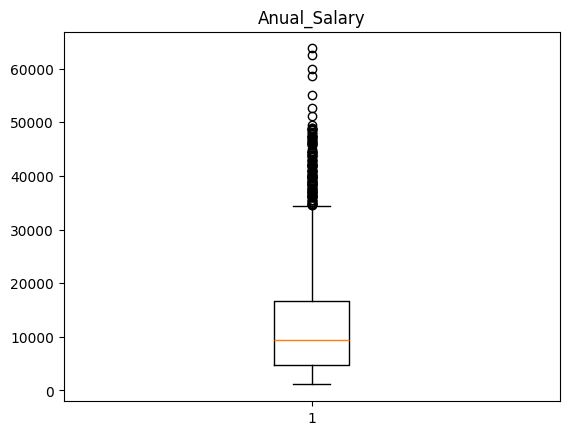

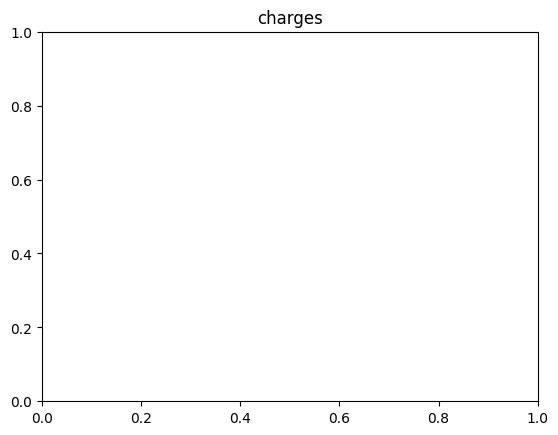

In [ ]:
for i in df.columns:
  if df[i].dtype !="object":
   plt.boxplot(df[i])
   plt.show()
   plt.title(i)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
outliers_col = ['bmi','past_consultations','Hospital_expenditure','Anual_Salary']

In [ ]:
# Handle Outliers
for i in outliers_col:
        if column in df.columns:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


In [ ]:
# handling the object columns -> Encoding
# label encoding -> Encoding  the data into alphabatical order

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
if df[i].dtype =='object':
  le=LabelEncoder()
  df[i]=le.fit_transform(df[i])


In [ ]:
for i in df.columns:
  if df[i].dtype == "object":
    le=LabelEncoder()
    df[i]=le.fit_transform(df[i])

In [ ]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1116 entries, 0 to 1115
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1116 non-null   float64
 1   sex                              1116 non-null   int64  
 2   bmi                              1116 non-null   float64
 3   children                         1116 non-null   float64
 4   smoker                           1116 non-null   int64  
 5   Claim_Amount                     1116 non-null   float64
 6   past_consultations               1116 non-null   float64
 7   num_of_steps                     1116 non-null   float64
 8   Hospital_expenditure             1116 non-null   float64
 9   NUmber_of_past_hospitalizations  1116 non-null   float64
 10  Anual_Salary                     1116 non-null   float64
 11  region                           1116 non-null   int64  
 12  charges                  

In [ ]:
# Build our model

In [ ]:
# split the data(Independance(x) and Dependent(y))

In [ ]:
x=df.drop(columns=['charges'])

In [ ]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1111,25.0,1,24.985,2.0,0,62860.68914,9.0,999973.0,1.772978e+07,2.0,5.436506e+08,0
1112,53.0,0,22.880,1.0,1,55113.73508,14.0,999111.0,2.089326e+07,2.0,5.619347e+08,2
1113,28.0,0,24.320,1.0,0,42171.46225,26.0,1012087.0,1.306414e+07,2.0,5.847415e+08,0
1114,49.0,1,25.600,2.0,1,43564.76221,20.0,993898.0,1.575212e+07,2.0,6.222796e+08,3


In [ ]:
y = df['charges']

In [ ]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1111,23241.47453
1112,23244.79020
1113,23288.92840
1114,23306.54700


In [ ]:
# split the data into train and test

from sklearn.model_selection import train_test_split

In [ ]:
#random_state =0 to infinite

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=32)

In [ ]:
df.shape

(1116, 13)

In [ ]:
x_train.shape

(892, 12)

In [ ]:
y_train.shape

(892,)

In [ ]:
x_test.shape

(224, 12)

In [ ]:
y_test.shape

(224,)

In [ ]:
# Train the model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# test the model

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([ 8021.27141811, 19237.72769129,  7245.14694088,  8473.98682963,
       18718.85644434,  6956.9386436 ,  3766.05453595, 19325.88748706,
        8396.31262562, 17890.59936678, 17667.43390049,  7288.40120287,
        4197.68081886, 17882.01619141,  6848.62557862,  3707.78152419,
        3697.18725236, 10865.9261286 ,   589.33788507,  2206.10506503,
       13594.09394538,  9491.20364724,  7527.8283873 ,  8892.51090335,
       11205.42153863,  4521.12270443,  6423.78868796, 19018.42963466,
       11829.29497613,  1781.09509138,  2000.81836824,  1912.22913856,
       10519.60754003,  9615.98185331, 10310.80876117,  9879.76910399,
        3467.12409605, 11180.06041374, 11610.17193496, 10613.31287616,
        9853.02979981,  2396.5771913 ,  3999.13931214, 12868.178386  ,
        1720.38796978,  8689.55193744, 22585.13177334, 21061.98838453,
        3090.18936491,  6491.36622485,  9375.08029239,  4381.39490077,
        2403.25386447,  6008.28338158, 14402.9639766 ,  7645.50998282,
      

In [ ]:
#Evaluation-->>

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_test,y_pred)

0.9600697387925388